# Convolving G-LiHT to EMIT spectral sampling

This tutorial takes a real **G-LiHT VNIR reflectance swath** and convolves it to
the **EMIT** band centers using `srfforge`. The result shows what a co-located
EMIT pixel would see over the same terrain in the shared VNIR spectral range.

| | G-LiHT VNIR (source) | EMIT (target) |
|---|---|---|
| Instrument | Headwall Micro-Hyperspec E-Series | Dyson imaging spectrometer |
| Range | 400–1000 nm | 366–2500 nm |
| Sampling | ~1.6 nm/band | ~7.5 nm/band |
| FWHM | ~5 nm | ~8.5 nm |
| Spatial res. | ~1 m (airborne) | ~60 m (spaceborne) |

> **Coverage note:** G-LiHT VNIR covers 400–1000 nm; EMIT extends to 2500 nm.
> Only EMIT bands in the 400–1000 nm overlap region will be well-weighted.
> EMIT bands above 1000 nm will be zero in the convolved output.

---
## 1. Setup

### Option A — conda (recommended)
```bash
conda env create -f environment.yml
conda activate srfforge
```

### Option B — pip
```bash
pip install -e ".[full]"
pip install spectral          # required for ENVI file reading
```

G-LiHT data is served over plain HTTPS — no login required.

In [1]:
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from srfforge import BandConvolver, GLiHT, EMIT
from srfforge.plot import rgb_quicklook

---
## 2. Download G-LiHT data

We use a G-LiHT VNIR reflectance swath over Alaska (10 July 2014) from the
NASA GSFC G-LiHT data portal. No account is required — files are served over
plain HTTPS.

The tar.gz contains an **ENVI binary + header** pair:
- `*_refl_VIs`     — float32 reflectance cube (lines × samples × bands)
- `*_refl_VIs.hdr` — ENVI header with per-band wavelengths, FWHM, and geometry

The metadata PDF documents the flight campaign, site, and instrument configuration.

In [2]:
DATA_DIR = Path("data/gliht")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://glihtdata.gsfc.nasa.gov/files/G-LiHT/AK_10Jul2014"

downloads = {
    f"{BASE_URL}/hyperspec/swath/AK_10Jul2014_l20s87_refl_VIs.tar.gz":
        DATA_DIR / "AK_10Jul2014_l20s87_refl_VIs.tar.gz",
    f"{BASE_URL}/metadata/AK_10Jul2014_metadata.pdf":
        DATA_DIR / "AK_10Jul2014_metadata.pdf",
}

for url, dest in downloads.items():
    if dest.exists():
        print(f"  already have  {dest.name}  ({dest.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"  downloading   {dest.name} ...", end=" ", flush=True)
        urllib.request.urlretrieve(url, dest)
        print(f"done  ({dest.stat().st_size / 1e6:.1f} MB)")

  already have  AK_10Jul2014_l20s87_refl_VIs.tar.gz  (1079.1 MB)
  already have  AK_10Jul2014_metadata.pdf  (0.0 MB)


In [3]:
tar_path = DATA_DIR / "AK_10Jul2014_l20s87_refl_VIs.tar.gz"

# Only extract if we haven't already
hdr_candidates = sorted(DATA_DIR.rglob("*refl*.hdr"))
if not hdr_candidates:
    print("Extracting ...", end=" ", flush=True)
    with tarfile.open(tar_path) as tf:
        tf.extractall(DATA_DIR)
    hdr_candidates = sorted(DATA_DIR.rglob("*refl*.hdr"))
    print("done")

print("Found ENVI headers:")
for h in hdr_candidates:
    print(f"  {h.relative_to(DATA_DIR)}")

hdr_path = hdr_candidates[0]
print(f"\nUsing: {hdr_path.name}")

Found ENVI headers:
  AK_10Jul2014_l20s87_at-sensor_refl_L1G.hdr

Using: AK_10Jul2014_l20s87_at-sensor_refl_L1G.hdr


---
## 3. Read G-LiHT reflectance

G-LiHT products are stored as **ENVI binary** (float32, BIL or BIP interleave).
The `.hdr` header contains per-band wavelengths and FWHM used to build the
`GLiHT` instrument object.

We use `spectral` if available; otherwise fall back to a plain numpy reader.

In [4]:
import spectral

img  = spectral.open_image(str(hdr_path))
meta = img.metadata

full_gb = img.nrows * img.ncols * img.nbands * 4 / 1e9
print(f"Full swath     : {img.nrows} lines × {img.ncols} samples × {img.nbands} bands")
print(f"Full size      : {full_gb:.1f} GB as float32")

# ── Stride-sample to cover the full swath length at reduced line resolution ───
# Loading every N-th row gives the same memory footprint as a contiguous crop
# but preserves the full diagonal shape of the flight path.
TARGET_LINES = 500
stride = max(1, img.nrows // TARGET_LINES)
sample_rows = list(range(0, img.nrows, stride))

print(f"Stride         : every {stride} lines → {len(sample_rows)} rows loaded")
raw = img.read_subimage(sample_rows, range(img.ncols)).astype(np.float32)
print(f"Loaded         : {raw.shape}  ({raw.nbytes / 1e6:.0f} MB)")

# ── Fill value ────────────────────────────────────────────────────────────────
fill_key = next((k for k in meta if "ignore" in k.lower() or "fill" in k.lower()), None)
fill_val = float(meta[fill_key]) if fill_key else -9999.0
raw[raw == fill_val] = np.nan

# ── Scale factor ──────────────────────────────────────────────────────────────
scale_key = next(
    (k for k in meta if "scale" in k.lower() and "factor" in k.lower()), None
)
scale = float(meta[scale_key]) if scale_key else 10000.0
if scale > 1.0:
    raw /= scale

# ── Sanity / no-data mask ─────────────────────────────────────────────────────
raw[raw < 0]   = np.nan    # residual fill after scaling
raw[raw > 1.5] = np.nan    # unphysical reflectance
# Edge-of-swath pixels in geocorrected G-LiHT products are stored as all-zero
raw[(raw == 0).all(axis=-1)] = np.nan

gliht_refl = raw

print(f"\nScale factor      : {scale}")
print(f"Fill value        : {fill_val}")
print(f"Reflectance range : {np.nanmin(gliht_refl):.4f} – {np.nanmax(gliht_refl):.4f}")
print(f"Valid pixels      : {np.isfinite(gliht_refl[:, :, 0]).mean():.1%}")

Full swath     : 4511 lines × 7761 samples × 114 bands
Full size      : 16.0 GB as float32
Stride         : every 9 lines → 502 rows loaded
Loaded         : (502, 7761, 114)  (1777 MB)

Scale factor      : 10000.0
Fill value        : -9999.0
Reflectance range : 0.0000 – 0.6892
Valid pixels      : 10.1%


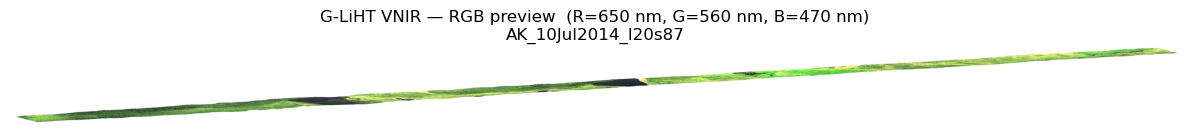

In [5]:
gliht_inst = GLiHT(hdr_file=hdr_path)

def _band_idx(wl, target):
    return int(np.argmin(np.abs(wl - target)))

rgb_raw = gliht_refl[:, :, [
    _band_idx(gliht_inst.wavelengths, 650),
    _band_idx(gliht_inst.wavelengths, 560),
    _band_idx(gliht_inst.wavelengths, 470),
]]
p98 = np.nanpercentile(rgb_raw, 98)
rgb_raw = np.clip(rgb_raw / p98, 0, 1)
rgb_raw = np.where(np.isnan(rgb_raw), 1.0, rgb_raw)   # NaN → white background

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(rgb_raw)
ax.set_title("G-LiHT VNIR — RGB preview  (R=650 nm, G=560 nm, B=470 nm)\nAK_10Jul2014_l20s87")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 4. Set up instruments

`GLiHT(hdr_file=...)` reads the per-acquisition wavelengths and FWHM directly
from the ENVI header — more accurate than the nominal spec-sheet values.

`EMIT()` uses the bundled nominal wavelengths (288 bands, 366–2500 nm).
If you have a co-located EMIT `.nc` file, use `EMIT(srf_file=nc_path)` instead
to get per-acquisition wavelengths from that scene.

In [7]:
gliht = GLiHT(hdr_file=hdr_path)   # per-acquisition wavelengths from .hdr
emit  = EMIT()                      # nominal 288-band EMIT

print(gliht)
print(emit)

# EMIT bands that fall within the G-LiHT VNIR range (half-FWHM margin on each side)
emit_in_gliht = (
    (emit.wavelengths >= gliht.wavelengths[0]  + emit.fwhm) &
    (emit.wavelengths <= gliht.wavelengths[-1] - emit.fwhm)
)
print(f"\nEMIT bands covered by G-LiHT : {emit_in_gliht.sum()}  "
      f"({emit.wavelengths[emit_in_gliht][0]:.0f}–{emit.wavelengths[emit_in_gliht][-1]:.0f} nm)")
print(f"EMIT bands outside G-LiHT    : {(~emit_in_gliht).sum()}  (will be ~zero)")

GLiHT(n_bands=114, range=418.4–918.6 nm)
EMIT(n_bands=288, range=366.0–2500.2 nm)

EMIT bands covered by G-LiHT : 65  (433–910 nm)
EMIT bands outside G-LiHT    : 223  (will be ~zero)


In [8]:
conv = BandConvolver(source=gliht, target=emit)
print(f"Convolution matrix : {conv.matrix.shape}  (EMIT bands × G-LiHT bands)")
rs = conv.matrix[emit_in_gliht].sum(axis=1)
print(f"Row sums — covered EMIT bands (should be ~1.0):")
print(f"  min={rs.min():.3f}  max={rs.max():.3f}")

Convolution matrix : (288, 114)  (EMIT bands × G-LiHT bands)
Row sums — covered EMIT bands (should be ~1.0):
  min=1.000  max=1.000


---
## 5. Convolve G-LiHT → EMIT

A single matrix multiply maps each G-LiHT pixel from ~1.6 nm sampling to
EMIT's ~7.5 nm bands. NaN pixels are zeroed before the multiply and
restored afterward so they don't propagate into the output.

In [9]:
nan_mask   = np.isnan(gliht_refl).any(axis=-1)              # (lines, samples)
refl_clean = np.where(np.isnan(gliht_refl), 0.0, gliht_refl)

gliht_as_emit = conv(refl_clean).astype(np.float32)         # (lines, samples, 288)
gliht_as_emit[nan_mask] = np.nan

print(f"G-LiHT original        : {gliht_refl.shape}")
print(f"Convolved to EMIT      : {gliht_as_emit.shape}")
print(f"EMIT bands with signal : {emit_in_gliht.sum()} / {len(emit.wavelengths)}")

G-LiHT original        : (502, 7761, 114)
Convolved to EMIT      : (502, 7761, 288)
EMIT bands with signal : 65 / 288


---
## 6. Visualise

### 6a. Spectral comparison — G-LiHT vs convolved to EMIT

/var/folders/4y/vdf6lk8d18qf_nvdqb40_nfw0000gn/T/ipykernel_66793/2629547850.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


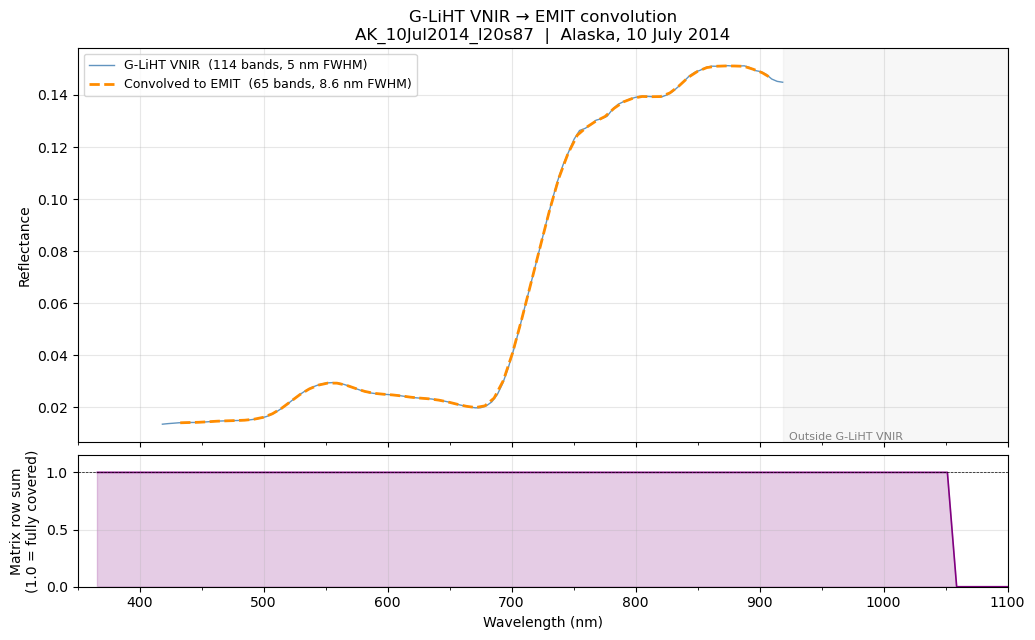

Saved: gliht_to_emit_spectra.png


In [10]:
src_flat = gliht_refl.reshape(-1, gliht_refl.shape[-1])
tgt_flat = gliht_as_emit.reshape(-1, gliht_as_emit.shape[-1])
valid = np.isfinite(src_flat).all(axis=1)
idx = np.random.default_rng(0).choice(
    np.where(valid)[0], size=min(500, valid.sum()), replace=False
)

gliht_mean = src_flat[idx].mean(axis=0)
emit_mean  = tgt_flat[idx].mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

axes[0].plot(gliht.wavelengths, gliht_mean, lw=1.0, color="steelblue", alpha=0.85,
             label=f"G-LiHT VNIR  ({len(gliht.wavelengths)} bands, {gliht.fwhm.mean():.0f} nm FWHM)")
axes[0].plot(emit.wavelengths[emit_in_gliht], emit_mean[emit_in_gliht],
             lw=2, ls="--", color="darkorange",
             label=f"Convolved to EMIT  ({emit_in_gliht.sum()} bands, {emit.fwhm.mean():.1f} nm FWHM)")
axes[0].axvspan(gliht.wavelengths[-1], 1100, alpha=0.06, color="gray")
axes[0].text(gliht.wavelengths[-1] + 5, gliht_mean.max() * 0.05,
             "Outside G-LiHT VNIR", fontsize=8, color="gray")
axes[0].set_ylabel("Reflectance")
axes[0].set_title(
    "G-LiHT VNIR → EMIT convolution\n"
    "AK_10Jul2014_l20s87  |  Alaska, 10 July 2014"
)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Row sums show which EMIT bands are fully covered by G-LiHT
row_sums = conv.matrix.sum(axis=1)
axes[1].plot(emit.wavelengths, row_sums, lw=1.2, color="purple")
axes[1].fill_between(emit.wavelengths, 0, row_sums, alpha=0.2, color="purple")
axes[1].axhline(1.0, color="k", lw=0.5, ls="--")
axes[1].set_ylabel("Matrix row sum\n(1.0 = fully covered)")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylim(0, 1.15)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlim(350, 1100)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))

plt.tight_layout()
plt.savefig(DATA_DIR / "gliht_to_emit_spectra.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gliht_to_emit_spectra.png")

### 6b. RGB quicklooks

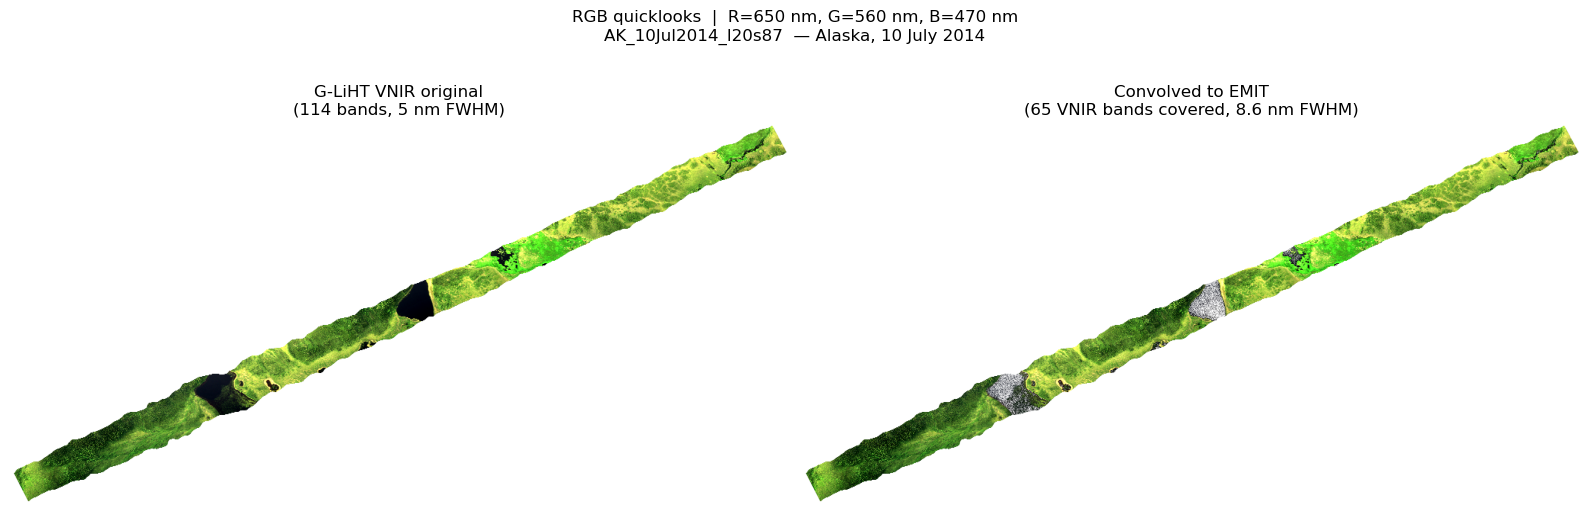

Saved: gliht_to_emit_rgb.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rgb_quicklook(gliht_refl,    instrument=gliht, ax=axes[0], aspect="auto")
rgb_quicklook(gliht_as_emit, instrument=emit,  ax=axes[1], aspect="auto")

axes[0].set_title(
    f"G-LiHT VNIR original\n"
    f"({len(gliht.wavelengths)} bands, {gliht.fwhm.mean():.0f} nm FWHM)"
)
axes[1].set_title(
    f"Convolved to EMIT\n"
    f"({emit_in_gliht.sum()} VNIR bands covered, {emit.fwhm.mean():.1f} nm FWHM)"
)
fig.suptitle(
    "RGB quicklooks  |  R=650 nm, G=560 nm, B=470 nm\n"
    "AK_10Jul2014_l20s87  — Alaska, 10 July 2014",
    y=1.02,
)
fig.tight_layout()
fig.savefig(DATA_DIR / "gliht_to_emit_rgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gliht_to_emit_rgb.png")